# 🎓 Семинар: Обучение линейной модели на классификацию аудио

На этом занятии мы разберем полный цикл обучения классификатора речевых цифр:
1. Загрузим датасет **AudioMNIST**
2. Напишем кастомный `Dataset`
3. Реализуем **линейные слои с ручным `forward` и `backward`**
4. Добавим активацию **ReLU** и второй слой
5. Напишем **SGD-оптимизатор**
6. Запустим полный цикл обучения

In [1]:
import os
import glob
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

torch.manual_seed(42)
np.random.seed(42)

## Загрузка AudioMNIST

Датасет содержит ~30 000 аудиофайлов с записями произнесения цифр от 0 до 9.

Каждый файл имеет частоту дискретизации 16 кГц и длительность ~1 сек. Мы будем приводить все сэмплы к фиксированной длине `16000` точек.

In [2]:
%pip install gdown -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import gdown
import zipfile

FILE_ID = "13E8JVJdNYS9K9ubdGcruLSMLUD10OLbx"
output = "audio_mnist.zip"

if not os.path.exists(output):
    gdown.download(id=FILE_ID, output=output, quiet=False)

# Распаковка
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")

KeyboardInterrupt: 

## Реализация `torch.utils.data.Dataset`

Класс должен реализовывать:
- `__len__`: возвращает количество семплов
- `__getitem__`: загружает аудио, приводит к фиксированной длине, нормализует, возвращает тензор и метку

In [2]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, target_len=16000):
        self.root_dir = root_dir
        self.target_len = target_len
        self.files = []
        self.labels = []

        # Сканируем все папки дикторов (00, 01, ..., 59)
        speaker_dirs = [d for d in glob.glob(os.path.join(root_dir, "*")) if os.path.isdir(d)]

        for speaker_dir in speaker_dirs:
            wav_paths = glob.glob(os.path.join(speaker_dir, "*.wav"))
            for wav_path in wav_paths:
                # Извлекаем метку из имени файла: "5_00_12.wav" -> "5"
                basename = os.path.basename(wav_path)
                label_str = basename.split("_")[0]

                # Безопасная проверка, что метка цифра от 0 до 9
                if label_str.isdigit() and (int(label_str) == 9 or int(label_str) == 0):
                    self.files.append(wav_path)
                    self.labels.append(0 if int(label_str) == 0 else 1)

        # Сортируем для воспроизводимости
        sorted_pairs = sorted(zip(self.labels, self.files))
        self.labels, self.files = [list(x) for x in zip(*sorted_pairs)]

        print(f"Найдено {len(self.files)} аудиофайлов")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        wav_path = self.files[idx]
        label = self.labels[idx]

        # Загрузка аудио
        waveform, sr = torchaudio.load(wav_path)

        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0)

        # Padding / Truncation до target_len
        if waveform.shape[1] < self.target_len:
            pad = self.target_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :self.target_len]

        # Нормализация в [-1, 1]
        waveform = waveform.squeeze()
        peak = waveform.abs().max()
        if peak > 0:
            waveform = waveform / peak

        return waveform.float(), torch.tensor(label, dtype=torch.long)

In [3]:
train_dataset = AudioMNISTDataset('data', target_len=16000)

Найдено 6000 аудиофайлов


In [4]:
train_dataset[0]

(tensor([ 0.0238,  0.0222,  0.0238,  ..., -0.6238, -0.6476, -0.6683]),
 tensor(0))

## Кастомный линейный слой

Формула прямого распространения (Forward):
$$ \mathbf{y} = \mathbf{x} \mathbf{W}^\top + \mathbf{b} $$
где:
- $\mathbf{x} \in \mathbb{R}^{B \times D_{in}}$ — вход (batch size $B$, входов $D_{in}$)
- $\mathbf{W} \in \mathbb{R}^{D_{out} \times D_{in}}$ — веса
- $\mathbf{b} \in \mathbb{R}^{D_{out}}$ — смещение
- $\mathbf{y} \in \mathbb{R}^{B \times D_{out}}$ — выход

Градиенты (Backward) вычисляются через цепное правило:
$$ \frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \delta^\top \mathbf{x}, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \sum_{i=1}^B \delta_i, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{x}} = \delta \mathbf{W} $$
где $\delta = \frac{\partial \mathcal{L}}{\partial \mathbf{y}}$ — градиент, пришедший с последующего слоя.

In [5]:
class ManualLinear:
    def __init__(self, in_features, out_features):
        # Инициализация весов (Kaiming uniform)
        scale = np.sqrt(2.0 / in_features)
        self.W = torch.randn(out_features, in_features) * scale
        self.b = torch.zeros(out_features)
        self.W.requires_grad = False  # Мы будем обновлять вручную
        self.b.requires_grad = False

    def forward(self, x):
        self.input = x  # Сохраняем для backward
        return x @ self.W.T + self.b # x [количество файликов, размер in_feature (16000)] @ [in_feature, out_feateru] = [количество файликов, out_feature]

    def backward(self, grad_output):
        # grad_output имеет shape (batch, out_features)
        # Градиенты по параметрам
        self.grad_W = grad_output.T @ self.input
        self.grad_b = grad_output.sum(dim=0)

        # Градиент по входу (для передачи назад)
        grad_input = grad_output @ self.W
        return grad_input

In [6]:
lin_layer = ManualLinear(10, 5)

In [7]:
x = torch.randn(10, 10)

y = lin_layer.forward(x)
y

tensor([[ 1.6859,  0.1786, -0.2065,  0.0080,  0.1552],
        [ 1.1944, -0.5960, -0.8017,  1.1430,  0.2847],
        [ 1.8632, -1.1329, -1.9791, -0.8873, -0.3043],
        [ 1.7891,  0.0342,  1.7894, -0.2422, -0.3067],
        [ 0.0264, -1.1971,  0.6991, -0.3664,  0.9737],
        [ 0.0658, -0.9189,  0.6217, -0.2734, -0.8440],
        [-0.5927, -0.4652, -0.4648,  0.3920, -0.2248],
        [-3.1857,  0.3316,  0.6955,  1.4301,  1.9856],
        [ 4.1595, -0.8406, -0.4053, -0.9114, -2.8410],
        [-2.4884, -1.4263,  2.5467, -0.2641,  1.1903]])

In [8]:
grad = torch.randn(10, 5)

in_grad = lin_layer.backward(grad)
in_grad.shape

torch.Size([10, 10])

In [9]:
# [a, b] @ [b, c] @ [c, d] = [a, b] @ [b, d]

## ReLU и полный градиентный спуск

**ReLU Forward:**
$$ a = \max(0, z) $$
**ReLU Backward:**
$$ \frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a} \odot \mathbb{I}(z > 0) $$

**Loss:** Cross-Entropy
$$ \mathcal{L} = -\frac{1}{B} \sum_{i=1}^B \sum_{c=1}^C y_{i,c} \log(\hat{y}_{i,c}) $$
Градиент по логитам последнего слоя:
$$ \delta^{(L)} = \frac{1}{B} (\text{softmax}(\mathbf{z}^{(L)}) - \mathbf{Y}_{\text{one-hot}}) $$

In [10]:
class RELU:
    def __init__(self):
        pass

    def forward(self, x):
        self.input = x
        
        return x * (x > 0)

    def backward(self, grad_output):
        return grad_output * (self.input > 0)

In [11]:
f = RELU()

x = torch.randn(10, 10)
f.forward(x)

tensor([[1.7290e-01, 1.0514e+00, 7.4915e-03, -0.0000e+00, 6.4269e-01, 5.7425e-01,
         5.8672e-01, -0.0000e+00, -0.0000e+00, 1.4840e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, 5.1580e-01, -0.0000e+00, 2.1962e-01,
         5.6351e-01, 1.8582e+00, 1.0441e+00, -0.0000e+00],
        [8.3509e-01, -0.0000e+00, 2.6911e-01, 8.5404e-02, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, 7.9039e-01, 5.2394e-01, -0.0000e+00],
        [-0.0000e+00, 1.2588e-03, 8.6374e-01, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         7.9865e-01, 9.1047e-01, -0.0000e+00, 3.3700e-01],
        [-0.0000e+00, 3.1630e-01, 3.8657e-01, 7.3369e-01, 2.5103e-01, 7.6999e-02,
         -0.0000e+00, 2.1698e+00, 5.2296e-01, 9.7173e-01],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, 8.7128e-01, -0.0000e+00,
         3.4628e-01, -0.0000e+00, 8.5686e-01, -0.0000e+00],
        [1.0682e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, 2.1368e-01, -0.0000e+00,
         1.8592e+00, 5.6125e-02, 7.6942e-01, 2.5574e+0

In [12]:
grad = torch.randn(10, 10)

f.backward(grad)

tensor([[ 4.0854e-01, -1.2609e+00,  9.1652e-01, -0.0000e+00, -2.1844e-01,
          1.6630e-01,  2.1442e+00,  0.0000e+00,  0.0000e+00,  5.4476e-01],
        [ 0.0000e+00,  0.0000e+00, -0.0000e+00, -1.1808e+00, -0.0000e+00,
          4.4849e-01,  4.9029e-01, -4.3747e-01, -1.2201e+00, -0.0000e+00],
        [ 6.6637e-01, -0.0000e+00, -2.0960e-01,  1.6632e-01, -0.0000e+00,
          0.0000e+00,  0.0000e+00,  2.1882e+00, -9.8515e-01, -0.0000e+00],
        [-0.0000e+00,  8.4358e-01, -3.1824e-01,  0.0000e+00,  0.0000e+00,
         -0.0000e+00,  2.4700e-02, -1.0641e+00, -0.0000e+00, -4.0751e-01],
        [ 0.0000e+00,  3.7145e-01,  2.6968e-01,  7.8999e-01,  9.4461e-01,
         -1.5824e+00,  0.0000e+00,  1.1457e+00, -2.7107e+00, -6.1301e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00, -0.0000e+00, -5.1608e-01,
          0.0000e+00,  4.1451e-01,  0.0000e+00,  1.3947e+00, -0.0000e+00],
        [-4.8333e-01, -0.0000e+00,  0.0000e+00,  0.0000e+00, -3.0158e-01,
         -0.0000e+00, -1.3271e+0

In [13]:
class ManualMLP:
    def __init__(self, input_dim, hidden_dim, num_classes):
        self.fc1 = ManualLinear(input_dim, hidden_dim)
        self.fc2 = ManualLinear(hidden_dim, num_classes)
        self.relu = RELU()
        

    def forward(self, x):
        self.input = x
        self.x = self.fc1.forward(x)
        self.z = self.relu.forward(self.x)
        self.y = self.fc2.forward(self.z)
        
        return self.y

    def compute_loss(self, logits, targets):

        log_probs = torch.log_softmax(logits, dim=1)
        batch_size = log_probs.shape[0]
        selected_log_probs = log_probs[torch.arange(batch_size), targets.to(torch.long)]
        loss = -selected_log_probs.mean()

        return loss

    def backward(self, targets):

        B = targets.shape[0]

        prob = torch.softmax(self.y, dim=1)

        one_hot = torch.zeros_like(self.y)
        one_hot.scatter_(1, targets.unsqueeze(1), 1.0)

        grad = (prob - one_hot) / B

        grad_1 = self.fc2.backward(grad)

        grad_2 = self.relu.backward(grad_1)
        
        grad_3 = self.fc1.backward(grad_2)

In [14]:
model = ManualMLP(10, 20, 2)

In [15]:
x = torch.randn(5, 10)
y = torch.ones(5)

y_t = model.forward(x)

model.compute_loss(y_t, y)

tensor(0.3394)

## Оптимизатор SGD

Правило обновления параметров:
$$ \theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L} $$
где $\eta$ — learning rate.

Мы реализуем простой класс, который проходит по всем параметрам модели и применяет градиентный шаг.

In [16]:
class ManualSGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                # Доступ к градиенту через атрибуты слоя
                # Для удобства мы временно прикрепим градиенты к параметрам в backward
                pass

    # Переопределим для удобства вызова внутри цикла
    @staticmethod
    def sgd_step(model, lr):
        with torch.no_grad():
            model.fc1.W -= lr * model.fc1.grad_W
            model.fc1.b -= lr * model.fc1.grad_b
            model.fc2.W -= lr * model.fc2.grad_W
            model.fc2.b -= lr * model.fc2.grad_b
            

## Полный цикл обучения

1. Инициализация модели, даталоадера и оптимизатора
2. `epoch` loop:
   - Прямой проход: `logits = model(x)`
   - Вычисление ошибки
   - Обратный проход: `model.backward(y)`
   - Обновление весов: `ManualSGD.sgd_step(model, lr)`
3. Логирование метрик и визуализация

In [17]:
# Параметры
BATCH_SIZE = 64
LR = 0.05
EPOCHS = 5
HIDDEN_DIM = 128

In [18]:
# 1. Создаём полный датасет (или подмножество для ускорения семинара)
full_dataset = AudioMNISTDataset('data', target_len=16000)

# 2. Разделяем 80/20 с фиксированным seed
train_ratio = 0.8
train_size = int(len(full_dataset) * train_ratio)
val_size = len(full_dataset) - train_size

train_ds, val_ds = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Найдено 6000 аудиофайлов
Train: 4800 | Val: 1200


In [19]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [20]:
model = ManualMLP(input_dim=16000, hidden_dim=HIDDEN_DIM, num_classes=2)

In [21]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

In [22]:
for epoch in range(EPOCHS):
    train_loss_sum, train_correct, train_total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} | Train", leave=False)
    for x_batch, y_batch in pbar:
        
        pred = model.forward(x_batch)

        loss = model.compute_loss(pred, y_batch)

        model.backward(y_batch)

        ManualSGD.sgd_step(model, lr=LR)

        # Метрики
        train_loss_sum += loss.item() * x_batch.size(0)
        preds = torch.argmax(pred, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += x_batch.size(0)

    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            pred = model.forward(x_batch)

            loss = model.compute_loss(pred, y_batch)

            val_loss_sum += loss.item() * x_batch.size(0)
            preds = torch.argmax(pred, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += x_batch.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val   Loss: {val_loss:.4f} Acc: {val_acc:.2%}")

Epoch 1 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.5876 Acc: 69.23% | Val   Loss: 0.4831 Acc: 81.58%


Epoch 2 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.3348 Acc: 91.35% | Val   Loss: 0.3882 Acc: 86.42%


Epoch 3 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.2053 Acc: 95.90% | Val   Loss: 0.3376 Acc: 87.83%


Epoch 4 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 04 | Train Loss: 0.1337 Acc: 97.79% | Val   Loss: 0.3139 Acc: 88.83%


Epoch 5 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 05 | Train Loss: 0.0877 Acc: 99.17% | Val   Loss: 0.3001 Acc: 88.58%


## Результаты обучения

Графики показывают сходимость функции ошибки и рост точности. Обратите внимание, что без регуляризации и сложной архитектуры модель быстро упирается в плато (~60-70%), что типично для полносвязной сети на сырых аудиосэмплах.

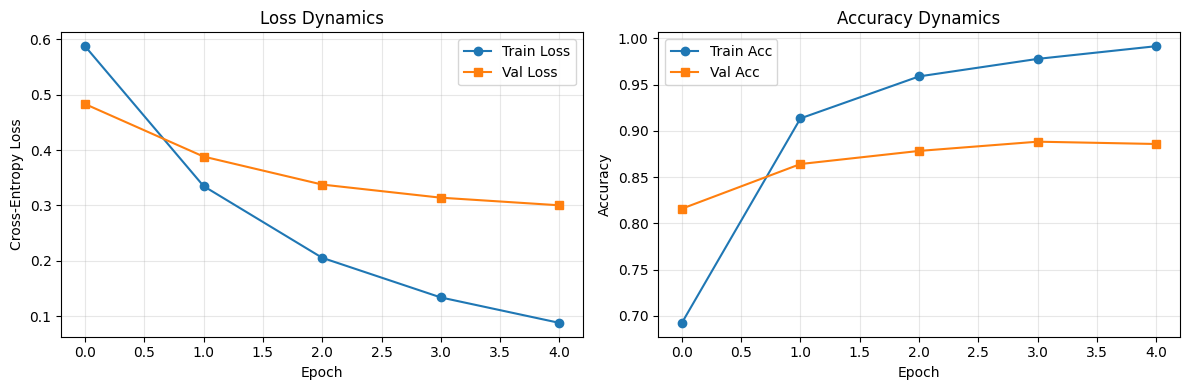

In [23]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Loss Dynamics")

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], marker="o", label="Train Acc")
plt.plot(history["val_acc"], marker="s", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Accuracy Dynamics")

plt.tight_layout()
plt.show()